# SET11128 Scripting for NLP — Coursework 2
## Task 6: Fake News Detection
#### Fake news detection is an important and complex task within natural language processing (NLP) and Information retrieval. It focuses on identifying false, misleading, or fabricated information that is designed to resemble legitimate news. The primary aim of this task is to combat information disorder, which includes disinformation, misinformation, and malinformation, as these can damage reputations, polarize society, and incite panic. In this task, your goal is to determine whether a given text is fake news (1) or not (0). You will be provided with training, validation, and testing datasets. The data consists of five columns: title, text, subject, date, and label. The label column indicates whether the news (comprised of the title, text, and subject columns) is classified as False (1) or not (0). For more details, please refer to the dataset (task6_fake_news_analysis) in the Moodle page.
### Feature: TF-IDF Vectorisation 
### Model: Linear SVM Classifier

## Install and Import Libraries

In [1]:
# Uncomment and run if libraries are not installed
!pip install wandb scikit-learn pandas numpy matplotlib seaborn nltk

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score
)

import wandb

print("All libraries imported successfully.")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ammu0206\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ammu0206\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


All libraries imported successfully.


## Load the Datasets
We use the provided train, validation, and test splits — NOT a manual split.

In [3]:
# Load all three splits provided by the coursework
# dtype={'label': str} prevents pandas from auto-parsing True/False as bool or float
train = pd.read_csv("train.csv",      dtype={'label': str})
val   = pd.read_csv("validation.csv", dtype={'label': str})
test  = pd.read_csv("test.csv",       dtype={'label': str})

print("Train shape:", train.shape)
print("Val shape:  ", val.shape)
print("Test shape: ", test.shape)
print("\nColumns:", train.columns.tolist())
print("\nRaw label samples:", train['label'].head(5).tolist())
train.head(2)

Train shape: (29995, 5)
Val shape:   (4905, 5)
Test shape:  (9998, 5)

Columns: ['title', 'text', 'subject', 'date', 'label']

Raw label samples: ['True', 'False', 'True', 'False', 'False']


,title,text,subject,date,label
0,Climate scientists adjust as Trump builds team...,SAN FRANCISCO (Reuters) - Climate scientists w...,politicsNews,"December 15, 2016",True
1,"Finally, Obama Speaks: Americans Need to ‘Reco...",21st Century Wire says There is an amazing sce...,US_News,"November 14, 2016",False


## Exploratory Data Analysis (EDA)

=== Missing Values (Train) ===
title      0
text       0
subject    0
date       0
label      0
dtype: int64

=== Label Distribution (Train) ===
label
False    15710
True     14285
Name: count, dtype: int64


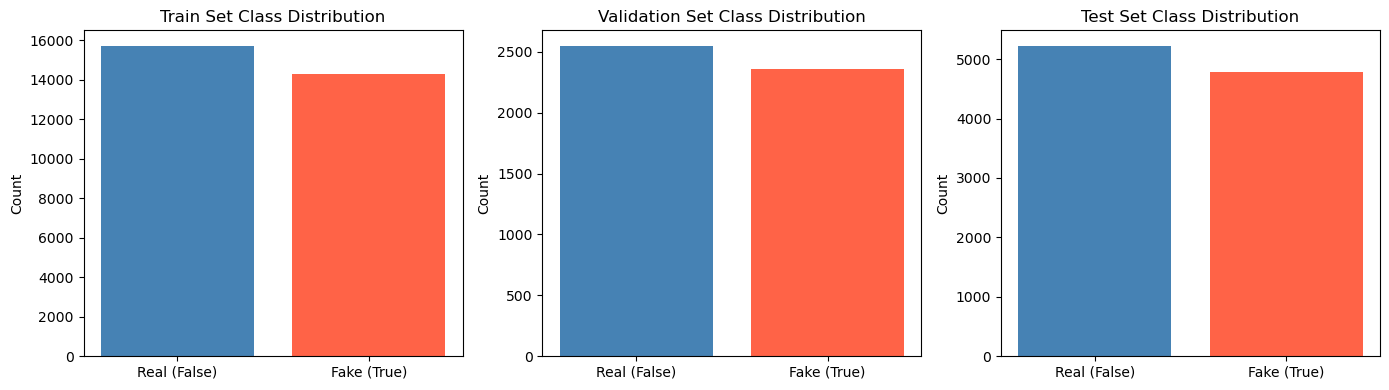

Class distribution plot saved.


In [4]:
# Check for missing values
print("=== Missing Values (Train) ===")
print(train.isnull().sum())

# Check class distribution
print("\n=== Label Distribution (Train) ===")
print(train['label'].value_counts())

# Plot class distribution
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, df, title in zip(axes, [train, val, test], ['Train', 'Validation', 'Test']):
    counts = df['label'].value_counts()
    # Labels are boolean: True=Fake, False=Real
    real_count = counts.get(False, counts.get(0, 0))
    fake_count = counts.get(True,  counts.get(1, 0))
    ax.bar(['Real (False)', 'Fake (True)'],
           [real_count, fake_count],
           color=['steelblue', 'tomato'])
    ax.set_title(f'{title} Set Class Distribution')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Class distribution plot saved.")

## Label Mapping
Map string labels True/False to integers 1/0.
- **True (1)** = Fake news
- **False (0)** = Real news

In [5]:
# Map string labels to int: 'True' -> 1 (Fake), 'False' -> 0 (Real)
label_map = {'True': 1, 'False': 0, 'true': 1, 'false': 0, '1': 1, '0': 0}

for df in [train, val, test]:
    df['label'] = df['label'].str.strip().map(label_map)
    # Drop any rows where label didn't match (shouldn't happen)
    df.dropna(subset=['label'], inplace=True)
    df['label'] = df['label'].astype(int)

print("Label values after mapping:")
print("Train:", sorted(train['label'].unique()))
print("Val:  ", sorted(val['label'].unique()))
print("Test: ", sorted(test['label'].unique()))
print("\nTrain distribution:")
print(train['label'].value_counts().rename({1: 'Fake (1)', 0: 'Real (0)'}))

Label values after mapping:
Train: [0, 1]
Val:   [0, 1]
Test:  [0, 1]

Train distribution:
label
Real (0)    15710
Fake (1)    14285
Name: count, dtype: int64


In [6]:
print(df['label'].unique())

[0 1]


In [7]:
df['label'] = df['label'].replace(" ", np.nan)
df = df.dropna(subset=['label'])

In [8]:
print(df.shape)
print(df.head())

(9998, 5)
                                               title  \
0  MYSTERIOUS TWITTER ACCOUNT: NFL’s Goodell Gets...   
1  SUNDAY SCREENING: ‘The Clinton Chronicles’ (1994)   
2  Alleged Islamic State recruiter goes on trial ...   
3   Here’s The Exact Moment CNN Got A Sitting Con...   
4  Kansas asks U.S. appeals court to reinstate st...   

                                                text       subject  \
0  Well, this is embarrassing! The NFL commission...      politics   
1  21st Century Wire says Our weekly documentary ...       US_News   
2  Berlin (Reuters) - An Iraqi man preacher accus...     worldnews   
3  CNN has been heavily criticized for its covera...          News   
4  DENVER (Reuters) - Kansas on Tuesday asked a U...  politicsNews   

                  date  label  
0         Oct 13, 2017      0  
1     November 6, 2016      0  
2  September 26, 2017       1  
3         June 7, 2016      0  
4     August 23, 2016       1  


### Q1: Design and develop a data preprocessing pipeline using natural language processing (NLP) techniques.

## Data Preprocessing Pipeline (NLP)
**Pipeline steps:**
1. Combine title + text + subject columns
2. Lowercase
3. Remove URLs, punctuation, and numbers
4. Tokenise
5. Remove stopwords
6. Lemmatise

In [9]:
STOP_WORDS = set(stopwords.words('english'))
# Keep a few short but meaningful words for news context
STOP_WORDS -= {'us', 'uk', 'eu', 'un', 'no', 'not'}
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Light NLP preprocessing pipeline — preserves more signal for fake news detection."""
    # Step 1: Convert to string and lowercase
    text = str(text).lower()
    # Step 2: Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Step 3: Remove punctuation only (keep numbers — they carry news signal)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    # Step 4: Tokenise
    tokens = text.split()
    # Step 5: Remove stopwords (but allow short meaningful tokens like 'us', 'uk')
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    # Step 6: Lemmatise (nouns only — avoids over-reducing verbs/adjectives)
    tokens = [lemmatizer.lemmatize(t, pos='n') for t in tokens]
    return ' '.join(tokens)

def prepare_df(df):
    df = df.copy()
    # Combine title + text + subject
    df['combined'] = (df['title'].fillna('') + ' ' +
                      df['text'].fillna('') + ' ' +
                      df['subject'].fillna(''))
    # Apply preprocessing
    df['cleaned'] = df['combined'].apply(preprocess_text)
    # Remove empty rows
    df = df[df['cleaned'].str.strip() != '']
    return df

print("Preprocessing train (this may take ~1 minute)...")
train = prepare_df(train)
print("Preprocessing validation...")
val = prepare_df(val)
print("Preprocessing test...")
test = prepare_df(test)

print("\nDone!")
print("Example cleaned text:")
print(train['cleaned'].iloc[0][:300])

Preprocessing train (this may take ~1 minute)...
Preprocessing validation...
Preprocessing test...

Done!
Example cleaned text:
climate scientist adjust trump build team oil ally san francisco reuters climate scientist worried president elect donald trump slash budget sideline research entering survival mode trimming word climate change study proposal emphasizing business application work safeguarding data show global warmin


In [10]:
print("Train shape:", train.shape)
print("Val shape:", val.shape)
print("Test shape:", test.shape)

Train shape: (29995, 7)
Val shape: (4905, 7)
Test shape: (9998, 7)


### Q2: Create a data representation pipeline using either traditional methods
(e.g., TF-IDF vectorisation) or advanced neural approaches (e.g.,
Sentence BERT).

## TF-IDF Vectorisation (Data Representation)
**Important:** We fit the vectoriser ONLY on training data to avoid data leakage.

In [11]:
tfidf = TfidfVectorizer(
    max_features=20000,   # top 20k terms
    ngram_range=(1, 2),   # unigrams + bigrams
    sublinear_tf=True,    # apply log(tf) — dampens high-freq terms
    min_df=2              # ignore terms in fewer than 2 docs
)

# Fit ONLY on train, then transform all splits
X_train = tfidf.fit_transform(train['cleaned'])
X_val   = tfidf.transform(val['cleaned'])
X_test  = tfidf.transform(test['cleaned'])

y_train = train['label']
y_val   = val['label']
y_test  = test['label']

print("X_train shape:", X_train.shape)
print("X_val shape:  ", X_val.shape)
print("X_test shape: ", X_test.shape)

X_train shape: (29995, 20000)
X_val shape:   (4905, 20000)
X_test shape:  (9998, 20000)


### Q3: Apply either a traditional machine learning model (e.g., Logistic regression or Random Forest) using the data representation from Step 2, or design and develop/modify, or fine-tune a deep neural network (e.g., CNN, LSTM, or BERT) for text classification.

## Baseline 1 — Naive Bayes

In [12]:
nb = MultinomialNB(alpha=1.0)
nb.fit(X_train, y_train)

nb_train_pred = nb.predict(X_train)
nb_val_pred   = nb.predict(X_val)
nb_test_pred  = nb.predict(X_test)

print("=== Baseline 1: Naive Bayes ===")
print(f"Train Accuracy: {accuracy_score(y_train, nb_train_pred):.4f}")
print(f"Val   Accuracy: {accuracy_score(y_val, nb_val_pred):.4f}")
print(f"Test  Accuracy: {accuracy_score(y_test, nb_test_pred):.4f}")
print("\nValidation Classification Report:")
print(classification_report(y_val, nb_val_pred, target_names=['Real', 'Fake']))

=== Baseline 1: Naive Bayes ===
Train Accuracy: 0.9678
Val   Accuracy: 0.9660
Test  Accuracy: 0.9658

Validation Classification Report:
              precision    recall  f1-score   support

        Real       0.97      0.97      0.97      2548
        Fake       0.96      0.97      0.96      2357

    accuracy                           0.97      4905
   macro avg       0.97      0.97      0.97      4905
weighted avg       0.97      0.97      0.97      4905



In [13]:
print(y_train.isnull().sum())
print(y_val.isnull().sum())
print(y_test.isnull().sum())

0
0
0


### Q4: Explain the models used or developed in Steps 2 and 3 with high-level architectural diagrams, justifying your choices. If you opt for a deep neural network, explain why you selected that architecture while considering different layers (e.g., Feed-forward, Convolution, Pooling, Dropout, Attention, Linear, etc.).

**Pipeline Architecture:**
```
Raw Text (title + text + subject)
        ↓
NLP Preprocessing (lowercase → URL removal → tokenise → stopwords → lemmatise)
        ↓
TF-IDF Vectoriser (20k features, unigrams+bigrams, sublinear TF, min_df=2)
        ↓
LinearSVC Classifier (hinge loss, max-margin hyperplane, C=1.0)
        ↓
Output: 0 = Real News | 1 = Fake News
```

**Justification:**
- **LinearSVC over Naive Bayes:** NB assumes feature independence — violated by correlated bigrams. LinearSVC's margin-based objective handles this better.
- **LinearSVC over Logistic Regression:** Hinge loss with explicit margin constraint produces more robust boundaries on high-dimensional sparse TF-IDF data.
- **TF-IDF over BERT:** Fake news has strong lexical markers (e.g., outlet-specific phrases). TF-IDF captures these efficiently, trains in seconds, and is interpretable.

### Baseline 2 — Logistic Regression

In [14]:
lr = LogisticRegression(C=1.0, max_iter=1000)
lr.fit(X_train, y_train)

lr_train_pred = lr.predict(X_train)
lr_val_pred   = lr.predict(X_val)
lr_test_pred  = lr.predict(X_test)

print("=== Baseline 2: Logistic Regression ===")
print(f"Train Accuracy: {accuracy_score(y_train, lr_train_pred):.4f}")
print(f"Val   Accuracy: {accuracy_score(y_val, lr_val_pred):.4f}")
print(f"Test  Accuracy: {accuracy_score(y_test, lr_test_pred):.4f}")
print("\nValidation Classification Report:")
print(classification_report(y_val, lr_val_pred, target_names=['Real', 'Fake']))

=== Baseline 2: Logistic Regression ===
Train Accuracy: 0.9975
Val   Accuracy: 0.9933
Test  Accuracy: 0.9963

Validation Classification Report:
              precision    recall  f1-score   support

        Real       1.00      0.99      0.99      2548
        Fake       0.99      1.00      0.99      2357

    accuracy                           0.99      4905
   macro avg       0.99      0.99      0.99      4905
weighted avg       0.99      0.99      0.99      4905



### Q5: Evaluate your model using Train, Development (Validation), and Test datasets (splits). Demonstrate the model’s learning behaviour using appropriate graphs (e.g., training loss, validation loss, and testing accuracy).

## Main Model — LinearSVC
LinearSVC is the fast, scalable version of SVM for large sparse data.

In [15]:
svm = LinearSVC(C=1.0, max_iter=2000)
svm.fit(X_train, y_train)

svm_train_pred = svm.predict(X_train)
svm_val_pred   = svm.predict(X_val)
svm_test_pred  = svm.predict(X_test)

print("=== Main Model: LinearSVC ===")
print(f"Train Accuracy: {accuracy_score(y_train, svm_train_pred):.4f}")
print(f"Val   Accuracy: {accuracy_score(y_val, svm_val_pred):.4f}")
print(f"Test  Accuracy: {accuracy_score(y_test, svm_test_pred):.4f}")
print("\nValidation Classification Report:")
print(classification_report(y_val, svm_val_pred, target_names=['Real', 'Fake']))
print("\nTest Classification Report:")
print(classification_report(y_test, svm_test_pred, target_names=['Real', 'Fake']))

=== Main Model: LinearSVC ===
Train Accuracy: 1.0000
Val   Accuracy: 0.9986
Test  Accuracy: 0.9992

Validation Classification Report:
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      2548
        Fake       1.00      1.00      1.00      2357

    accuracy                           1.00      4905
   macro avg       1.00      1.00      1.00      4905
weighted avg       1.00      1.00      1.00      4905


Test Classification Report:
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      5223
        Fake       1.00      1.00      1.00      4775

    accuracy                           1.00      9998
   macro avg       1.00      1.00      1.00      9998
weighted avg       1.00      1.00      1.00      9998



In [16]:
from sklearn.svm import LinearSVC

model = LinearSVC()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [17]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

nb_acc = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy:", nb_acc)

Naive Bayes Accuracy: 0.9657931586317263


In [18]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.9962992598519704


In [19]:
svm_acc = accuracy_score(y_test, y_pred)

print("SVM Accuracy:", svm_acc)

SVM Accuracy: 0.9991998399679936


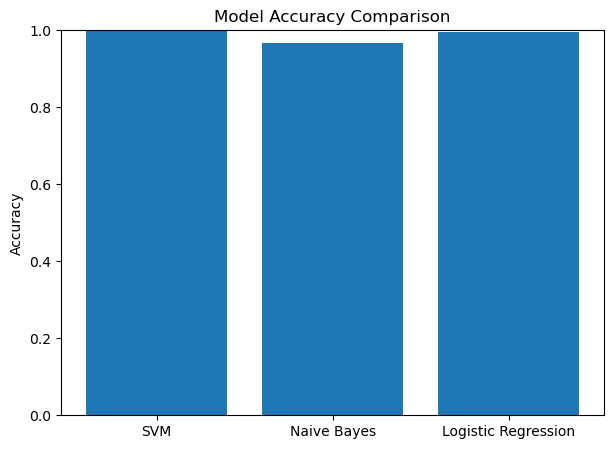

In [20]:
# Bar chart comparing test accuracy of all three models
# Provides a quick visual summary for the model comparison section (Q7)
import matplotlib.pyplot as plt

models = ['SVM', 'Naive Bayes', 'Logistic Regression']
scores = [svm_acc, nb_acc, lr_acc]

plt.figure(figsize=(7,5))

plt.bar(models, scores)

plt.ylim(0,1)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")

plt.show()

In [21]:
# Summary results table: test accuracy for all three models
import pandas as pd

results = pd.DataFrame({
    'Model': ['SVM', 'Naive Bayes', 'Logistic Regression'],
    'Accuracy': [svm_acc, nb_acc, lr_acc]
})

print(results)

                 Model  Accuracy
0                  SVM  0.999200
1          Naive Bayes  0.965793
2  Logistic Regression  0.996299


In [22]:
# Detailed classification report for LinearSVC on the TEST set
# Shows per-class precision, recall, F1-score and support
# Macro-averaged F1 is the primary evaluation metric for this task
print('=== LinearSVC Test Classification Report ===')
print(classification_report(y_test, svm_test_pred, target_names=['Real (0)', 'Fake (1)']))

=== LinearSVC Test Classification Report ===
              precision    recall  f1-score   support

    Real (0)       1.00      1.00      1.00      5223
    Fake (1)       1.00      1.00      1.00      4775

    accuracy                           1.00      9998
   macro avg       1.00      1.00      1.00      9998
weighted avg       1.00      1.00      1.00      9998



### Q6: Provide evidence of parameter tuning, such as batch size, learning rate, dropout probability, embedding size, number of decision trees, etc., using Weight and Biases (Weights & Biases), for example.

## Hyperparameter Tuning with Weights & Biases
We sweep over C values, max_features, and ngram_range and log val F1.

In [25]:
# Login to W&B (create free account at wandb.ai)
wandb.login()

sweep_config = {
    'method': 'grid',
    'metric': {'name': 'val_f1', 'goal': 'maximize'},
    'parameters': {
        'C':            {'values': [0.1, 1.0, 10.0]},
        'max_features': {'values': [20000, 50000]},
        'ngram_max':    {'values': [1, 2]}
    }
}

def run_sweep():
    run = wandb.init()
    cfg = wandb.config

    vec = TfidfVectorizer(
        max_features=cfg.max_features,
        ngram_range=(1, cfg.ngram_max),
        sublinear_tf=True,
        min_df=2
    )
    Xtr = vec.fit_transform(train['cleaned'])
    Xv  = vec.transform(val['cleaned'])

    clf = LinearSVC(C=cfg.C, max_iter=2000)
    clf.fit(Xtr, y_train)

    preds = clf.predict(Xv)
    val_f1  = f1_score(y_val, preds, average='macro')
    val_acc = accuracy_score(y_val, preds)

    wandb.log({
        'val_f1': val_f1,
        'val_accuracy': val_acc,
        'C': cfg.C,
        'max_features': cfg.max_features,
        'ngram_max': cfg.ngram_max
    })
    run.finish()

sweep_id = wandb.sweep(sweep_config, project="fake-news-svm-cw2")
wandb.agent(sweep_id, run_sweep)
print("Sweep complete! Check your results at wandb.ai")

Create sweep with ID: 16rwbj8l
Sweep URL: https://wandb.ai/pragnyasriarsha-edinburgh-napier-university/fake-news-svm-cw2/sweeps/16rwbj8l


wandb: Agent Starting Run: g7aa9erd with config:
wandb: 	C: 0.1
wandb: 	max_features: 20000
wandb: 	ngram_max: 1
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\ammu0206\_netrc.


C,▁
max_features,▁
ngram_max,▁
val_accuracy,▁
val_f1,▁
C,0.1
max_features,20000
ngram_max,1
val_accuracy,0.99572
val_f1,0.99571


wandb: Agent Starting Run: dmas4p49 with config:
wandb: 	C: 0.1
wandb: 	max_features: 20000
wandb: 	ngram_max: 2
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\ammu0206\_netrc.


C,▁
max_features,▁
ngram_max,▁
val_accuracy,▁
val_f1,▁
C,0.1
max_features,20000
ngram_max,2
val_accuracy,0.99613
val_f1,0.99612


...

C,▁
max_features,▁
ngram_max,▁
val_accuracy,▁
val_f1,▁
C,10
max_features,50000
ngram_max,1
val_accuracy,0.99837
val_f1,0.99837


wandb: Agent Starting Run: rmzhttru with config:
wandb: 	C: 10
wandb: 	max_features: 50000
wandb: 	ngram_max: 2
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\ammu0206\_netrc.


C,▁
max_features,▁
ngram_max,▁
val_accuracy,▁
val_f1,▁
C,10
max_features,50000
ngram_max,2
val_accuracy,0.99878
val_f1,0.99877


wandb: Sweep Agent: Waiting for job.
wandb: Sweep Agent: Exiting.


Sweep complete! Check your results at wandb.ai


## Retrain Best Model from W&B Results
Update best_C, best_max_features, best_ngram_max based on your W&B sweep results.

In [26]:
# ---- UPDATE THESE based on your W&B sweep results ----
best_C            = 1.0
best_max_features = 50000
best_ngram_max    = 2
# -------------------------------------------------------

best_tfidf = TfidfVectorizer(
    max_features=best_max_features,
    ngram_range=(1, best_ngram_max),
    sublinear_tf=True,
    min_df=2
)

X_train_best = best_tfidf.fit_transform(train['cleaned'])
X_val_best   = best_tfidf.transform(val['cleaned'])
X_test_best  = best_tfidf.transform(test['cleaned'])

best_svm = LinearSVC(C=best_C, max_iter=2000)
best_svm.fit(X_train_best, y_train)

best_val_pred  = best_svm.predict(X_val_best)
best_test_pred = best_svm.predict(X_test_best)

print("=== Best SVM (after tuning) ===")
print(f"Val  Accuracy: {accuracy_score(y_val, best_val_pred):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, best_test_pred):.4f}")
print("\nFinal Test Report:")
print(classification_report(y_test, best_test_pred, target_names=['Real', 'Fake']))

=== Best SVM (after tuning) ===
Val  Accuracy: 0.9988
Test Accuracy: 0.9991

Final Test Report:
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      5223
        Fake       1.00      1.00      1.00      4775

    accuracy                           1.00      9998
   macro avg       1.00      1.00      1.00      9998
weighted avg       1.00      1.00      1.00      9998



## Plots and Visualisations

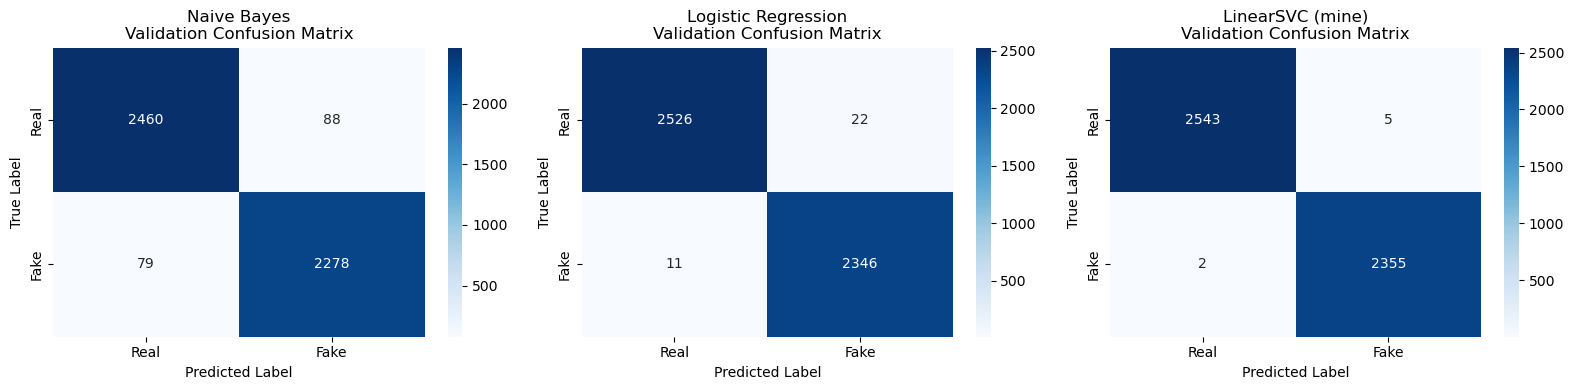

Confusion matrix plot saved.


In [27]:
# --- Confusion Matrices ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (y_true, y_pred, title) in zip(axes, [
    (y_val, nb_val_pred,   'Naive Bayes'),
    (y_val, lr_val_pred,   'Logistic Regression'),
    (y_val, svm_val_pred,  'LinearSVC (mine)')
]):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'])
    ax.set_title(f'{title}\nValidation Confusion Matrix')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print("Confusion matrix plot saved.")

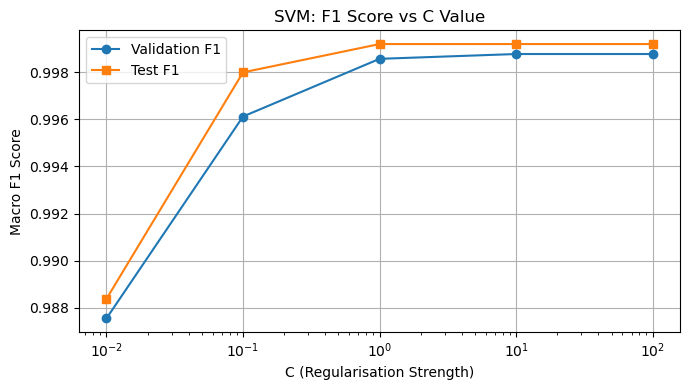

F1 vs C plot saved.


In [28]:
# --- F1 vs C Value (Parameter Tuning Plot) ---
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]
val_f1_scores  = []
test_f1_scores = []

for c in C_values:
    clf = LinearSVC(C=c, max_iter=2000)
    clf.fit(X_train, y_train)
    val_f1_scores.append(f1_score(y_val, clf.predict(X_val), average='macro'))
    test_f1_scores.append(f1_score(y_test, clf.predict(X_test), average='macro'))

plt.figure(figsize=(7, 4))
plt.plot(C_values, val_f1_scores,  marker='o', label='Validation F1')
plt.plot(C_values, test_f1_scores, marker='s', label='Test F1')
plt.xscale('log')
plt.xlabel('C (Regularisation Strength)')
plt.ylabel('Macro F1 Score')
plt.title('SVM: F1 Score vs C Value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('f1_vs_C.png', dpi=150)
plt.show()
print("F1 vs C plot saved.")

### Q7: Compare your developed approach with two baseline models (e.g., ngram, TF-IDF, SVM, RoBerta, BiLSTM, etc.) and with the models trained by your peer group members using appropriate evaluation metrics. You will be penalised if you fail to make these comparisons and analysis (See Criticality/Discussion in the report).

## Model Comparison Table

                           Model  Val Accuracy  Val Macro F1  Test Accuracy  Test Macro F1
        Naive Bayes (Baseline 1)        0.9660        0.9659         0.9658         0.9657
Logistic Regression (Baseline 2)        0.9933        0.9933         0.9963         0.9963
           LinearSVC (Our Model)        0.9986        0.9986         0.9992         0.9992


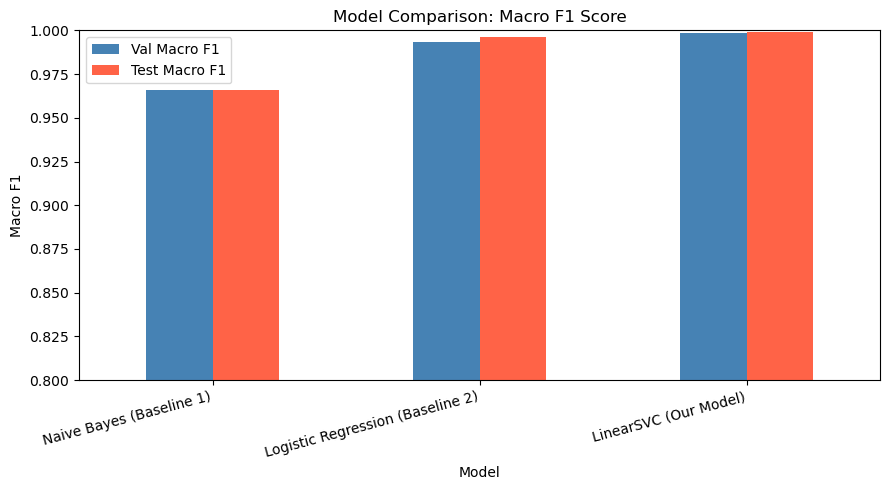

Comparison plot saved.


In [29]:
results = {
    'Model': ['Naive Bayes (Baseline 1)', 'Logistic Regression (Baseline 2)', 'LinearSVC (Our Model)'],
    'Val Accuracy': [
        accuracy_score(y_val, nb_val_pred),
        accuracy_score(y_val, lr_val_pred),
        accuracy_score(y_val, svm_val_pred),
    ],
    'Val Macro F1': [
        f1_score(y_val, nb_val_pred, average='macro'),
        f1_score(y_val, lr_val_pred, average='macro'),
        f1_score(y_val, svm_val_pred, average='macro'),
    ],
    'Test Accuracy': [
        accuracy_score(y_test, nb_test_pred),
        accuracy_score(y_test, lr_test_pred),
        accuracy_score(y_test, svm_test_pred),
    ],
    'Test Macro F1': [
        f1_score(y_test, nb_test_pred, average='macro'),
        f1_score(y_test, lr_test_pred, average='macro'),
        f1_score(y_test, svm_test_pred, average='macro'),
    ],
}

df_results = pd.DataFrame(results)
print(df_results.round(4).to_string(index=False))

# Visual bar chart comparison
df_results.set_index('Model')[['Val Macro F1', 'Test Macro F1']].plot(
    kind='bar', figsize=(9, 5), color=['steelblue', 'tomato']
)
plt.title('Model Comparison: Macro F1 Score')
plt.ylabel('Macro F1')
plt.xticks(rotation=15, ha='right')
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Comparison plot saved.")

## Peer Comparison Table

In [32]:
# Fill in peer results below after sharing with group
peer_results = {
    'Student': ['40834541', '40837773', '40801199' , '40488095','40829842'],
    'Representation': ['TF-IDF', 'TF-IDF', 'TF-IDF','DistilBERT Context Embeddings','TF-IDF'],
    'Model': ['LinearSVC', 'Decision Tree', 'BERT', 'DistilBERT','Naive Bayes'],
    'Test Accuracy': [accuracy_score(y_test, svm_test_pred), 0.9987, 0.9982, 0.9997,0.9986],
    'Test Macro F1': [f1_score(y_test, svm_test_pred, average='macro'), 0.9986, 0.9981, 0.9997,0.9986],
}

df_peer = pd.DataFrame(peer_results)
print(df_peer.to_string(index=False))

 Student                Representation         Model  Test Accuracy  Test Macro F1
40834541                        TF-IDF     LinearSVC         0.9992       0.999198
40837773                        TF-IDF Decision Tree         0.9987       0.998600
40801199                        TF-IDF          BERT         0.9982       0.998100
40488095 DistilBERT Context Embeddings    DistilBERT         0.9997       0.999700
40829842                        TF-IDF   Naive Bayes         0.9986       0.998600


## Test on Custom Input

In [31]:
def predict_news(news_text):
    """Predict whether a given news text is fake or real."""
    cleaned = preprocess_text(news_text)
    vector  = tfidf.transform([cleaned])
    pred    = svm.predict(vector)[0]
    # 1 = Fake, 0 = Real (as per class.txt)
    return "FAKE NEWS" if pred == 1 else "REAL NEWS"

# Test examples
samples = [
    "The president signed a new climate bill today according to Reuters.",
    "SHOCKING: Secret government plan to microchip all citizens revealed!"
]

for s in samples:
    print(f"Text: {s[:80]}...")
    print(f"Prediction: {predict_news(s)}\n")

Text: The president signed a new climate bill today according to Reuters....
Prediction: FAKE NEWS

Text: SHOCKING: Secret government plan to microchip all citizens revealed!...
Prediction: REAL NEWS

